In [190]:
# TO-DO
# smooth to 10 arcmin, add other maps?
# CHECK UNIT CONVERSIONS

# NOTES
# Note: map noise not incorporated in errors (background variation dominant anyway) for maps w/o noise (i.e. anything but COMAP)

In [191]:
# --- IMPORT STATEMENTS ---

import numpy as np
import healpy as hp
import scipy.constants as const
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import Gaussian2DKernel, convolve

In [192]:
# --- GLOBAL VARIABLES ---

LINUX_DIRECTORY = "/home/aimee/mphys"
FIGURE_SAVEDIR = "figures"
MAPS_DIR = "/home/aimee/mphys/data/maps"
FIGURE_SAVEDIR = "figures"
SAVE_FIGS = False

# Coordinates and radii of interesting sources (tweak)
# CHECK COORDS OF SECOND SOURCE - eyeballed (red region to right of GDIGS difference maps)
COORDS = [(30.13, 1.33), # (l, b) [degrees]
          (16.4, -0.15)
          ] 

RADII = [(5, 5), # (x, y) [arcmin] (minimum 2.5 due to beam size)
         (10, 10)
         ] 
# get known HII regions etc.

# Bg subtraction region sizes (tweak)
BG_FACTOR = 3 # times radius
BUFFER_FACTOR = 1.5 # times radius

# Smoothing
SMOOTHING_FWHM = 5 # arcmin

# MAP INFO

# Beam widths? (GET TRUE VALUES FOR ALL MAPS)
COMAP_FWHM = 4.5

# Maps and their frequencies

HALPHA_MAPS = { # name : [file name, frequency / Hz]
    "H-ALPHA 457 THz" : ["Halpha_map.fits", 457e12] # check frequency in map header
    }

COMAP_MAPS = { # name : [file name, frequency / Hz]
    "COMAP 26.5 GHz" : ["comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 26.5e9],
    "COMAP 27.5 GHz" : ["comap_alr-2_galactic_301025_band01_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 27.5e9],
    "COMAP 28.5 GHz" : ["comap_alr-2_galactic_301025_band02_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 28.5e9],
    "COMAP 29.5 GHz" : ["comap_alr-2_galactic_301025_band03_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 29.5e9],
    "COMAP 30.5 GHz" : ["comap_alr-2_galactic_301025_band04_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 30.5e9],
    "COMAP 31.5 GHz" : ["comap_alr-2_galactic_301025_band05_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 31.5e9],
    "COMAP 32.5 GHz" : ["comap_alr-2_galactic_301025_band06_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 32.5e9],
    "COMAP 33.5 GHz" : ["comap_alr-2_galactic_301025_band07_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 33.5e9]
}

# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index
EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    # "Effelsberg 1.43 GHz (10')" : ["EFFELSBERG-1.4285714285714286GHz-10.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (15')" : ["EFFELSBERG-1.4285714285714286GHz-15.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (20')" : ["EFFELSBERG-1.4285714285714286GHz-20.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (25')" : ["EFFELSBERG-1.4285714285714286GHz-25.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (30')" : ["EFFELSBERG-1.4285714285714286GHz-30.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (60')" : ["EFFELSBERG-1.4285714285714286GHz-60.0amin.fits", 1.4285714285714286e9],
    "Effelsberg 2.73 GHz (5')" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (1')" : ["Effelsberg_2.7272GHz_raw_1arcmin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (10')" : ["EFFELSBERG-2.7272727272727275GHz-10.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (15')" : ["EFFELSBERG-2.7272727272727275GHz-15.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (20')" : ["EFFELSBERG-2.7272727272727275GHz-20.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (25')" : ["EFFELSBERG-2.7272727272727275GHz-25.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (30')" : ["EFFELSBERG-2.7272727272727275GHz-30.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (60')" : ["EFFELSBERG-2.7272727272727275GHz-60.0amin.fits", 2.7272727272727275e9]
}

GDIGS_MAPS = { # name : [file name, frequency / Hz]
    # Note to self: create a GDIGS mosaic smoothed to 5 arcmin?
    "GDIGS Moment 0" : ["gdigs_moment0_mosaic_1arcmin.fits", 5.76e9]
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
    # "Nobeyama 10.0GHz (5')" : ["NOBEYAMA-10.0GHz-5.0amin.fits", 10.3e9]
    "Nobeyama 10.0GHz (1')" : ["Nobeyama_10.0GHz_raw_1arcmin.fits", 10.3e9]
    # "Nobeyama 10.0GHz (10')"  : ["NOBEYAMA-10.0GHz-10.0amin.fits", 9.4e9]
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    "PARKES 5GHz (1')" : ["Parkes_5.0GHz_raw_1arcmin.fits", 5e9], # mine (reproject - unreliable unless rebinned)
    # "PARKES 5GHz (5')" : ["PARKES-5.0GHz-5.0amin.fits", 5e9] # CORRUPTED
    # "PARKES 5GHz (10')" : ["PARKES-5.0GHz-10.0amin.fits", 5e9] # CORRUPTED
}


SINO_GERMAN_MAPS = { # name : [file name, frequency / Hz]
    "Sino German 5.0GHz (10')" : ["SinoGermanSurvey-5.0GHz-10.0amin.fits", 5e9]
}

AKARI_MAPS = { # name : [file name, frequency / Hz]
    "Akari 1875 GHz (5')" : ["AKARI-1874.9999999999998GHz-5.0amin.fits", 1874.9999999999998e9],
    # "Akari 1875 GHz (10')" : ["AKARI-1874.9999999999998GHz-10.0amin.fits", 1874.9999999999998e9],
    "Akari 2143 GHz (5')" : ["AKARI-2142.857142857143GHz-5.0amin.fits", 2142.857142857143e9],
    # "Akari 2143 GHz (10')" : ["AKARI-2142.857142857143GHz-10.0amin.fits", 2142.857142857143e9],
    "Akari 3333 GHz (5')" : ["AKARI-3333.333333333333GHz-5.0amin.fits", 3333.333333333333e9],
    # "Akari 3333 GHz (10')" : ["AKARI-3333.333333333333GHz-10.0amin.fits", 3333.333333333333e9],
    "Akari 4615 GHz (5')" : ["AKARI-4615.384615384616GHz-5.0amin.fits", 4615.384615384616e9],
    # "Akari 4615 GHz (10')" : ["AKARI-4615.384615384616GHz-10.0amin.fits", 4615.384615384616e9]
}

AMI_MAPS = {
    "AMI 15.7 GHz (5')": ["AMI-15.7GHz-5.0amin.fits", 15.7e9] # tiny range
}

BOLOCAM_MAPS = {} # CORRUPTED

CGPS_MAPS = {} # CORRUPTED

CHIPASS_MAPS = {} # don't have any <15 arcmin

IRIS_MAPS = { # name : [file name, frequency / Hz]
    "IRIS 3000 GHz (5')" : ["IRIS-3000.0GHz-5.0amin.fits", 3e12],
    "IRIS 5000 GHz (5')" : ["IRIS-5000.0GHz-5.0amin.fits", 5e12],
    "IRIS 12000 GHz (5')" : ["IRIS-12000.0GHz-5.0amin.fits", 12e12],
    "IRIS 25000 GHz (5')" : ["IRIS-25000.0GHz-5.0amin.fits", 25e12],
    }



In [193]:
# --- FUNCTION DEFINITIONS ---

In [194]:
def get_map(path, silent=True):
    
    if not silent:
        print(f"Getting data from {path}")
    
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)
    try:
        noise = fits_file[3].data # COMAP
    except:
        noise = np.full_like(data, 0) # set zero noise for other maps
        
    return data, noise, header, wcs

In [195]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = 0 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='red', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [196]:
def K_to_Jy_per_sr(temperature, frequency):
    
    # Rayleigh-Jeans law (brightness temp to brightness)
    brightness = 2 * frequency**2 * const.k * temperature / const.c**2 # W m^-2 Hz^-1 sr^-1
    brightness = brightness / 1e-26 # Jy sr^-1

    return brightness


def Jy_per_sr_to_Jy_per_pix(brightness_sr, pix_size_deg):
    
    pix_size_rad = pix_size_deg * np.pi/180
    sr_per_pix = pix_size_rad**2
    brightness_pix = brightness_sr * sr_per_pix

    return brightness_pix

In [197]:
def get_xy_lims(x_centre, y_centre, x_radius, y_radius, shape):
    
    x_min = int(np.floor(x_centre - BG_FACTOR * x_radius))
    x_max = int(np.ceil(x_centre + BG_FACTOR * x_radius))
    y_min = int(np.floor(y_centre - BG_FACTOR * y_radius))
    y_max = int(np.ceil(y_centre + BG_FACTOR * y_radius))

    # Clip to data boundaries
    x_min = max(x_min, 0)
    y_min = max(y_min, 0)
    x_max = min(x_max, shape[1])
    y_max = min(y_max, shape[0])


    return x_min, x_max, y_min, y_max

In [198]:
def read_region(data, noise, wcs, l_centre, b_centre, x_radius, y_radius):
    
    x_centre, y_centre = wcs.all_world2pix(float(l_centre), float(b_centre), 0)
    x_min, x_max, y_min, y_max = get_xy_lims(x_centre, y_centre, x_radius, y_radius, data.shape)
    
    # Isolate source and background
    source_pixels, source_noise_pixels, bg_pixels = [], [], []
    for x in range(x_min, x_max):
        for y in range(y_min, y_max):
            ellipse_val = ((x - x_centre) / x_radius)**2 + ((y - y_centre) / y_radius)**2
            if ellipse_val <= 1:  # inside ellipse
                source_pixels.append(data[y, x])
                source_noise_pixels.append(noise[y, x])
            elif (ellipse_val <= BG_FACTOR**2) & (ellipse_val >= BUFFER_FACTOR**2):  # elliptical background ring
                bg_pixels.append(data[y, x])

    # Calculate background mean and error
    bg_avg = np.nanmean(bg_pixels)
    bg_std = np.nanstd(bg_pixels)

    # Calculate average noise in source region
    noise_avg = np.nanmean(source_noise_pixels)

    # Calculate total error
    error = np.sqrt(bg_std**2 + noise_avg**2)

    # Background subtract
    source_pixels_bgsub = np.array(source_pixels) - bg_avg
    sum_bgsub = np.sum(source_pixels_bgsub)
    
    return sum_bgsub, error


In [199]:
def plot_cutout(map_title, ax, data, wcs, l_centre, b_centre, x_radius, y_radius):
    
    x_centre, y_centre = wcs.all_world2pix(float(l_centre), float(b_centre), 0)
    x_min, x_max, y_min, y_max = get_xy_lims(x_centre, y_centre, x_radius, y_radius, data.shape)
    cutout = data[y_min:y_max, x_min:x_max]
    
    # show cutout
    im = ax.imshow(cutout, origin='lower', cmap='viridis')
    cbar = ax.figure.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
    cbar.set_label('Jy/pixel')
    
    # add ellipses
    source_ellipse = Ellipse((x_centre - x_min, y_centre - y_min), 2*x_radius, 2*y_radius, linewidth=0.75, fill=False, edgecolor='white')
    bg_ellipse = Ellipse((x_centre - x_min, y_centre - y_min), 2*x_radius*BG_FACTOR, 2*y_radius*BG_FACTOR, linewidth=0.75, fill=False, edgecolor='red')
    buffer_ellipse = Ellipse((x_centre - x_min, y_centre - y_min), 2*x_radius*BUFFER_FACTOR, 2*y_radius*BUFFER_FACTOR, linewidth=0.75, fill=False, edgecolor='red')
    
    ax.add_patch(source_ellipse)
    ax.add_patch(bg_ellipse)
    ax.add_patch(buffer_ellipse)

    # axis labels and title
    ax.set_xlabel("l index [pix]")
    ax.set_ylabel("b index [pix]")
    ax.set_title(map_title)

In [200]:
def plot_cutout_all_maps(l, b, x_radius_pix, y_radius_pix):
    
    # Determine subplot grid size (e.g., 2 rows and 5 columns for 10 maps)
    num_maps = len(MAP_TITLES)
    ncols = 4  # Number of columns
    nrows = (num_maps + ncols - 1) // ncols  # Calculate the number of rows needed
    
    # Create subplots grid
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
    axes = axes.flatten()  # Flatten axes for easy iteration
    
    for i, map_title in enumerate(MAP_TITLES):
        ax = axes[i]  # Get the axis for the current subplot

        # Extract relevant map info
        data = DATA_ARR[i]
        wcs = WCS_ARR[i]
        
        # Call function to plot the region cutout for this map
        plot_cutout(map_title, ax, data, wcs, l, b, x_radius_pix, y_radius_pix)

    # Hide unused subplots (if number of maps is not a perfect multiple of ncols)
    for j in range(num_maps, len(axes)):
        axes[j].axis('off')

    plt.tight_layout() 
    plt.show()

In [201]:
def main(l, b, x_radius_arcmin, y_radius_arcmin):
    
    brightness_arr, brightness_err_arr = [], []
    for i, map_title in enumerate(MAP_TITLES):

        # load in map info
        data = DATA_ARR[i]
        noise = NOISE_ARR[i]
        header = HEADER_ARR[i]
        wcs = WCS_ARR[i]

        # Convert radius from arcmin to pixels
        arcmin_per_pix = np.abs(header['CDELT1'] * 60)
        x_radius_pix = x_radius_arcmin / arcmin_per_pix
        y_radius_pix = y_radius_arcmin / arcmin_per_pix

        # Aperture photometry
        brightness, brightness_err = read_region(data, noise, wcs, l, b, x_radius_pix, y_radius_pix) 
        # print(f'Brightness temperature = {brightness} +- {brightness_err} Jy/pixel') # DEBUG
        brightness_arr.append(brightness)
        brightness_err_arr.append(brightness_err)

    plot_cutout_all_maps(l, b, x_radius_pix, y_radius_pix)

    return brightness_arr, brightness_err_arr


In [202]:
def plot_spectrum_log(freq_arr, brightness_arr, brightness_err_arr, l, b):
    
    # Convert frequency to GHz, and take natural logs
    x = np.log(np.array(freq_arr) / 1e9)
    y = np.log(np.array(brightness_arr))
    y_err = np.abs(np.array(brightness_err_arr) / np.array(brightness_arr))

    # Plot
    plt.figure(figsize=(8, 6))
    plt.errorbar(x, y, yerr=y_err, fmt='x', linestyle='None', 
                 color='b', capsize=5, elinewidth=2)
    plt.xlabel(r"$\ln(\nu\ [\text{GHz}])$")
    plt.ylabel(r"$\ln(\text{Brightness}\ [\text{Jy/pixel}])$")
    plt.title(f"log-log Spectrum for Object at ({l}, {b})")
    plt.grid()
    plt.show()


def plot_spectrum(freq_arr, brightness_arr, brightness_err_arr, l, b):
    
    # Convert frequency to GHz
    x = np.array(freq_arr) / 1e9
    y = np.array(brightness_arr)
    y_err = np.array(brightness_err_arr)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.errorbar(x, y, yerr=y_err, fmt='x', linestyle='None', 
                 color='b', capsize=5, elinewidth=2)
    plt.xlabel(r"$\nu\ [\text{GHz}])$")
    plt.ylabel(r"$\text{Brightness}\ [\text{Jy/pixel}])$")
    plt.title(f"Spectrum for Object at ({l}, {b})")
    plt.grid()
    plt.show()

In [203]:
def sigma(FWHM1, FWHM2, scale):
    
    sigma = np.sqrt(abs(FWHM1**2 - FWHM2**2)) / (2*np.sqrt(2 * np.log(2)) * scale)
    
    return sigma

In [204]:
# --- MAIN CODE ---

# load in all maps (or else have to repeat loading in for every source)
MAP_TITLES, DATA_ARR, NOISE_ARR, HEADER_ARR, WCS_ARR, FREQ_ARR = [], [], [], [], [], []

# NOT INCLUDED: 
    # GDIGS - our 'SNR' is out of range, plus can only do theoretical units conversion
    # NOBEYAMA - our 'SNR' is out of range, plus not sure of units in T J Rennie's maps
    # SINO GERMAN - only have 10' map in Rennie's maps (make own instead?)
    # AMI - tiny range (our sources out of range)
    # H-ALPHA - frequency too high - messes with spectrum scale (plus not necessary since dropoff is earlier)
    # Don't yet have ACT, HFI, or Herschel/SPIRE (like in Gabriel's email)

#  COMAP
for i, map_title in enumerate(list(COMAP_MAPS.keys())):
    
    # Get data
    map_name = COMAP_MAPS[map_title][0]
    map_freq = COMAP_MAPS[map_title][1]
    path = f'{MAPS_DIR}/{map_name}'
    data, noise, header, wcs = get_map(path, silent=True)
    # plot_fits(data, wcs, title=f'{map_title} - K')
    
    # Convert K to Jy/pixel
    pix_size_deg = np.abs(header['CDELT1'])
    data = K_to_Jy_per_sr(data, map_freq)
    noise = K_to_Jy_per_sr(noise, map_freq)
    data = Jy_per_sr_to_Jy_per_pix(data, pix_size_deg)
    noise = Jy_per_sr_to_Jy_per_pix(noise, pix_size_deg)
    # plot_fits(data, wcs, title=f'{map_title} - Jy/pix')
    
    # # Smooth map 
    # # NOTE: takes a long time --> write separate code to smooth and save fits file, then read in here?
    # _, _, map_fwhm, _, _, _ = get_map_info(map_title)
    # # print(map_fwhm) # DEBUG
    # smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(map_fwhm, SMOOTHING_FWHM, 1))
    # data = convolve(data, smoothing_kernel, preserve_nan=True)
    # # plot_fits(data, wcs, title=f'{map_title} - Smoothed to {SMOOTHING_FWHM} arcmin')
    
    MAP_TITLES.append(map_title)
    DATA_ARR.append(data)
    NOISE_ARR.append(noise)
    HEADER_ARR.append(header)
    WCS_ARR.append(wcs)
    FREQ_ARR.append(map_freq)

# # EFFELSBERG
# for i, map_title in enumerate(list(EFFELSBERG_MAPS.keys())):
    
#     # Get data
#     map_name = EFFELSBERG_MAPS[map_title][0]
#     map_freq = EFFELSBERG_MAPS[map_title][1]
#     path = f'{MAPS_DIR}/{map_name}'
#     data, noise, header, wcs = get_map(path, silent=True)
#     # plot_fits(data, wcs, title=f'{map_title} - Jy/sr')
    
#     # Convert Jy/sr to Jy/pixel
#     pix_size_deg = np.abs(header['CDELT1'])
#     data = Jy_per_sr_to_Jy_per_pix(data, pix_size_deg)
#     noise = Jy_per_sr_to_Jy_per_pix(noise, pix_size_deg)
#     # plot_fits(data, wcs, title=f'{map_title} - Jy/pix')
    
#     MAP_TITLES.append(map_title)
#     DATA_ARR.append(data)
#     NOISE_ARR.append(noise)
#     HEADER_ARR.append(header)
#     WCS_ARR.append(wcs)
#     FREQ_ARR.append(map_freq)


# # PARKES
# for i, map_title in enumerate(list(PARKES_MAPS.keys())):
    
#     # Get data
#     map_name = PARKES_MAPS[map_title][0]
#     map_freq = PARKES_MAPS[map_title][1]
#     path = f'{MAPS_DIR}/{map_name}'
#     data, noise, header, wcs = get_map(path, silent=True)
#     # plot_fits(data, wcs, title=f'{map_title} - Jy/sr')
    
#     # Convert Jy/sr (?) to Jy/pixel
#     pix_size_deg = np.abs(header['CDELT1'])
#     data = Jy_per_sr_to_Jy_per_pix(data, pix_size_deg)
#     noise = Jy_per_sr_to_Jy_per_pix(noise, pix_size_deg)
#     # plot_fits(data, wcs, title=f'{map_title} - Jy/pix')
    
#     MAP_TITLES.append(map_title)
#     DATA_ARR.append(data)
#     NOISE_ARR.append(noise)
#     HEADER_ARR.append(header)
#     WCS_ARR.append(wcs)
#     FREQ_ARR.append(map_freq)
    
# # AKARI
# for i, map_title in enumerate(list(AKARI_MAPS.keys())):
    
#     # Get data
#     map_name = AKARI_MAPS[map_title][0]
#     map_freq = AKARI_MAPS[map_title][1]
#     path = f'{MAPS_DIR}/{map_name}'
#     data, noise, header, wcs = get_map(path, silent=True)
#     # plot_fits(data, wcs, title=f'{map_title} - Jy/sr')
    
#     # Convert Jy/sr (?) to Jy/pixel
#     pix_size_deg = np.abs(header['CDELT1'])
#     data = Jy_per_sr_to_Jy_per_pix(data, pix_size_deg)
#     noise = Jy_per_sr_to_Jy_per_pix(noise, pix_size_deg)
#     # plot_fits(data, wcs, title=f'{map_title} - Jy/pix')
    
#     MAP_TITLES.append(map_title)
#     DATA_ARR.append(data)
#     NOISE_ARR.append(noise)
#     HEADER_ARR.append(header)
#     WCS_ARR.append(wcs)
#     FREQ_ARR.append(map_freq)

# # IRIS
# for i, map_title in enumerate(list(IRIS_MAPS.keys())):
    
#     # Get data
#     map_name = IRIS_MAPS[map_title][0]
#     map_freq = IRIS_MAPS[map_title][1]
#     path = f'{MAPS_DIR}/{map_name}'
#     data, noise, header, wcs = get_map(path, silent=True)
#     # plot_fits(data, wcs, title=f'{map_title} - Jy/sr')
    
#     # Convert Jy/sr (?) to Jy/pixel
#     pix_size_deg = np.abs(header['CDELT1'])
#     data = Jy_per_sr_to_Jy_per_pix(data, pix_size_deg)
#     noise = Jy_per_sr_to_Jy_per_pix(noise, pix_size_deg)
#     # plot_fits(data, wcs, title=f'{map_title} - Jy/pix')
    
#     MAP_TITLES.append(map_title)
#     DATA_ARR.append(data)
#     NOISE_ARR.append(noise)
#     HEADER_ARR.append(header)
#     WCS_ARR.append(wcs)
#     FREQ_ARR.append(map_freq)

# Sort low to high frequency (for lattice plot)
combined = list(zip(FREQ_ARR, MAP_TITLES, DATA_ARR, NOISE_ARR, HEADER_ARR, WCS_ARR))
combined.sort() # sorts by first element (frequency)
FREQ_ARR, MAP_TITLES, DATA_ARR, NOISE_ARR, HEADER_ARR, WCS_ARR = map(list, zip(*combined))

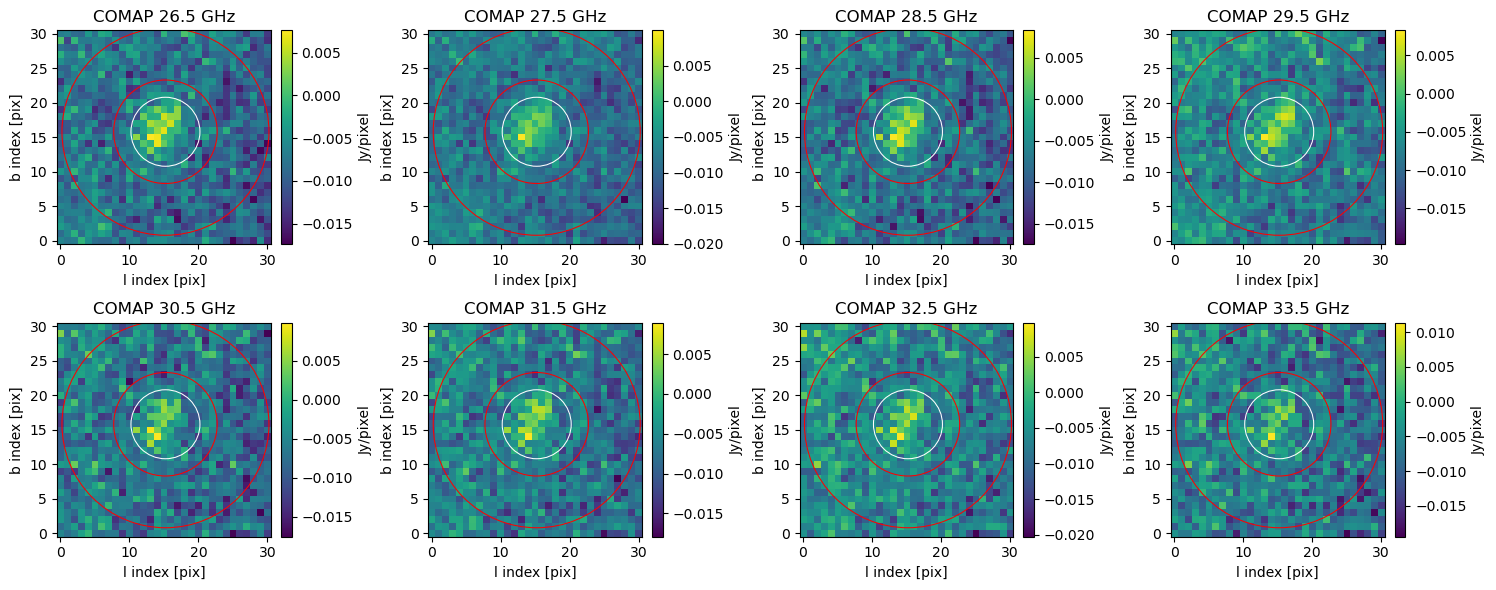

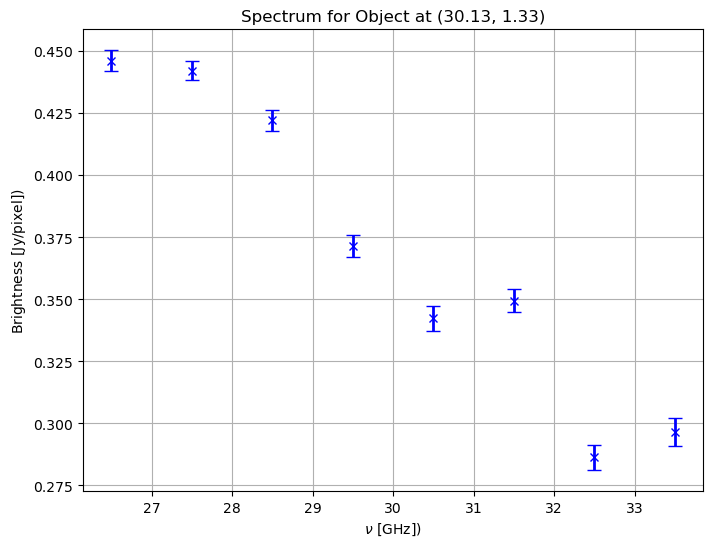

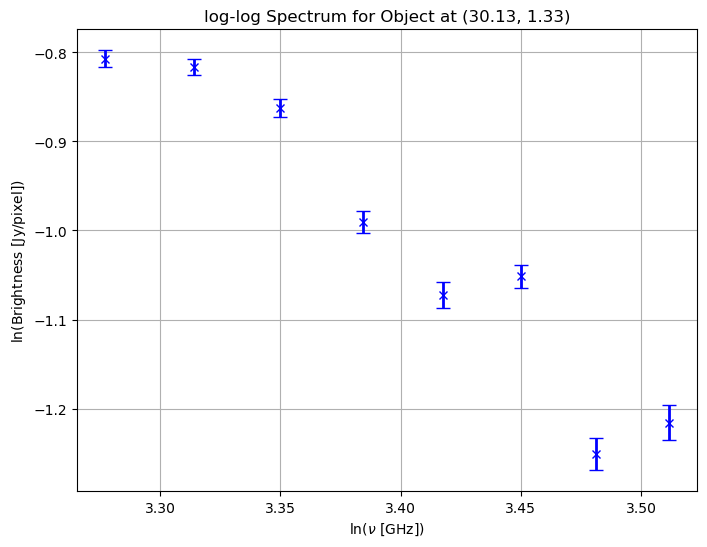

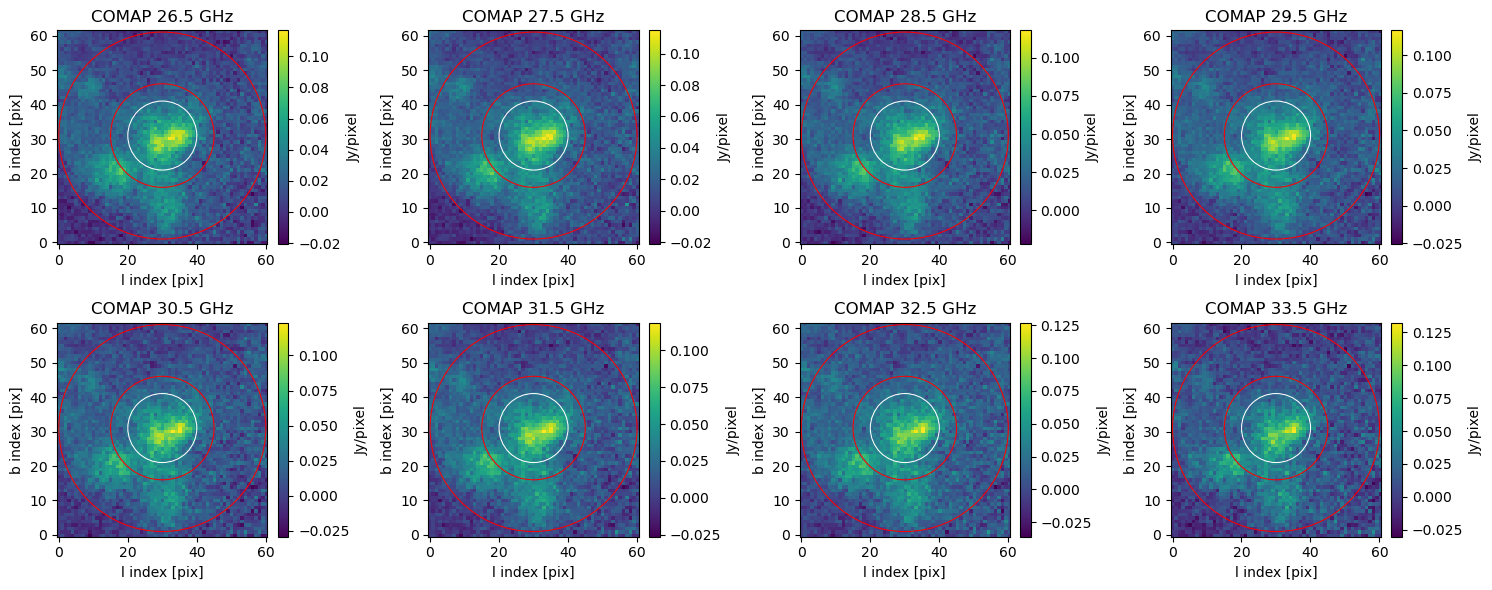

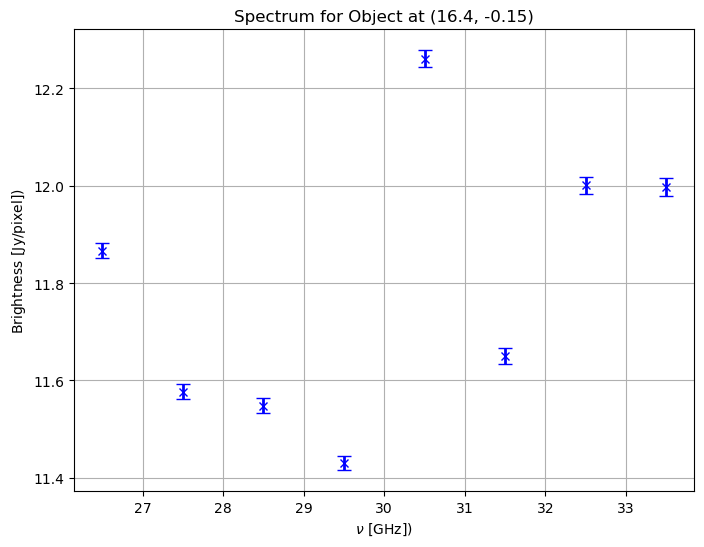

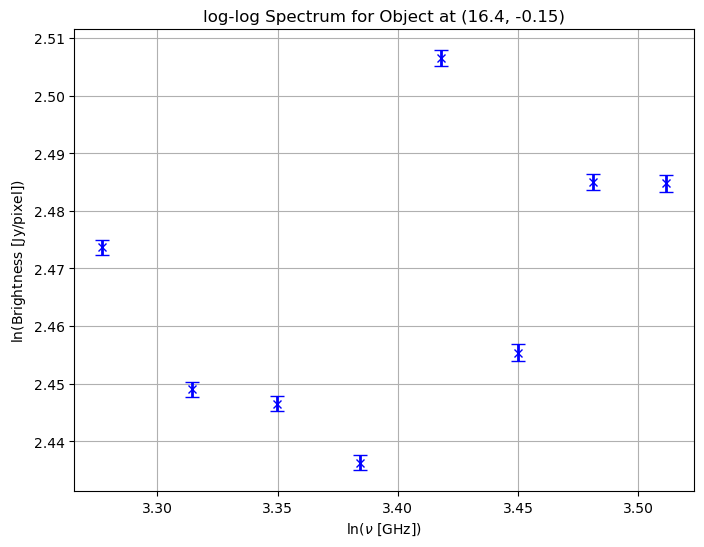

In [205]:
# Loop over all sources
for (l, b), (x_radius_arcmin, y_radius_arcmin) in zip(COORDS, RADII):
    brightness_arr, brightness_err_arr = main(l, b, x_radius_arcmin, y_radius_arcmin)

    # spectrum - flux vs frequency
    plot_spectrum(FREQ_ARR, brightness_arr, brightness_err_arr, l, b)
    plot_spectrum_log(FREQ_ARR, brightness_arr, brightness_err_arr, l, b)

In [206]:
# spectral index
np.log(35/23)/np.log(27.5/32.5)

# np.log(0.45/0.275)/np.log(26.5/32.5)


np.float64(-2.513280931782195)